In [2]:
# IMPORTS
import zipfile
import cdsapi
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import geopandas as gpd

from pathlib import Path
from rasterio.enums import Resampling
from scipy.stats import pearsonr, spearmanr
from scipy.ndimage import binary_dilation
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.spatial import cKDTree

In [3]:
# RUTAS DE TRABAJO
BASE    = Path(r"C:\Users\Gambo\Documents\Master Aaron\TFM UCM")
DATA    = BASE / "Data"
FIGURES = BASE / "Figures"

ERA5_RAW = DATA / "era5"
ERA5_EXTRACTED = DATA / "era5_extracted"
ruta_mdt = DATA / "MDT" / "mdt_spain.tif"
ruta_firespain = DATA / "firespain025_WGS84.nc"
ruta_provincias = (DATA / "SHP_ETRS89" / "ll_provinciales_inspire_peninbal_etrs89" / "ll_provinciales_inspire_peninbal_etrs89.shp")
ruta_civio = DATA / "CIVIO" / "fires-all.csv"
ruta_mdt_derivadas = DATA / "MDT" / "mdt_derivadas.nc"
ruta_mdt_025 = DATA / "MDT" / "mdt_025.nc"

# 2.1 ERA5-LAND

## - DESCARGA

In [4]:
# DESCARGA DE ERA5-LAND (EJECUTADA UNA ÚNICA VEZ)
# Los archivos se descargaron mediante la API de Copernicus CDS.
# Este bloque se conserva únicamente por reproducibilidad si se desea volver a descargar los datos
# cambiar Descargar_ERA5 a True y ejecutar el bloque.
# =============================================================================
DESCARGAR_ERA5 = False

if DESCARGAR_ERA5:
    c = cdsapi.Client()
    for year in range(2008, 2023):
        print(f"Descargando {year}...")
        meses = (["01"] if year == 2022 else [f"{m:02d}" for m in range(1, 13)])

        c.retrieve(
            "reanalysis-era5-land",
            {
                "variable": [
                    "volumetric_soil_water_layer_1",
                    "volumetric_soil_water_layer_2",
                    "2m_temperature",
                    "total_precipitation",
                ],
                "year": str(year),
                "month": meses,
                "day": [f"{d:02d}" for d in range(1, 32)],
                "time": "12:00",
                "data_format": "netcdf",
                "area": [44.0, -9.5, 35.0, 4.5],
            },
            ERA5_RAW / f"era5_land_{year}.nc",
        )

## - EXTRACCIÓN

In [5]:
for year in range(2008, 2023):
    zip_path = ERA5_RAW / f"era5_land_{year}.nc"
    out_path = ERA5_EXTRACTED / f"era5_land_{year}.nc"
    with zipfile.ZipFile(zip_path) as z:
        with z.open("data_0.nc") as src, open(out_path, "wb") as dst:
            dst.write(src.read())
        print(f"{year} -> {out_path}")

print("\nExtracción completada.")

2008 -> C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\era5_extracted\era5_land_2008.nc
2009 -> C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\era5_extracted\era5_land_2009.nc
2010 -> C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\era5_extracted\era5_land_2010.nc
2011 -> C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\era5_extracted\era5_land_2011.nc
2012 -> C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\era5_extracted\era5_land_2012.nc
2013 -> C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\era5_extracted\era5_land_2013.nc
2014 -> C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\era5_extracted\era5_land_2014.nc
2015 -> C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\era5_extracted\era5_land_2015.nc
2016 -> C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\era5_extracted\era5_land_2016.nc
2017 -> C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\era5_extracted\era5_land_2017.nc
2018 -> C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\era5_extracted\era5_l

## - VERIFICACIÓN PREVIA

In [6]:
archivos = sorted(ERA5_EXTRACTED.glob("era5_land_*.nc"))

for f in archivos:
    ds = xr.open_dataset(f)
    print(
        f"{f.name} | "
        f"tiempo: {len(ds.valid_time)} días | "
        f"lat: {len(ds.latitude)} | "
        f"lon: {len(ds.longitude)} | "
        f"vars: {list(ds.data_vars)}"
    )

    ds.close()

era5_land_2008.nc | tiempo: 366 días | lat: 91 | lon: 141 | vars: ['swvl1', 'swvl2', 't2m', 'tp']
era5_land_2009.nc | tiempo: 365 días | lat: 91 | lon: 141 | vars: ['swvl1', 'swvl2', 't2m', 'tp']
era5_land_2010.nc | tiempo: 365 días | lat: 91 | lon: 141 | vars: ['swvl1', 'swvl2', 't2m', 'tp']
era5_land_2011.nc | tiempo: 365 días | lat: 91 | lon: 141 | vars: ['swvl1', 'swvl2', 't2m', 'tp']
era5_land_2012.nc | tiempo: 366 días | lat: 91 | lon: 141 | vars: ['swvl1', 'swvl2', 't2m', 'tp']
era5_land_2013.nc | tiempo: 365 días | lat: 91 | lon: 141 | vars: ['swvl1', 'swvl2', 't2m', 'tp']
era5_land_2014.nc | tiempo: 365 días | lat: 91 | lon: 141 | vars: ['swvl1', 'swvl2', 't2m', 'tp']
era5_land_2015.nc | tiempo: 365 días | lat: 91 | lon: 141 | vars: ['swvl1', 'swvl2', 't2m', 'tp']
era5_land_2016.nc | tiempo: 366 días | lat: 91 | lon: 141 | vars: ['swvl1', 'swvl2', 't2m', 'tp']
era5_land_2017.nc | tiempo: 365 días | lat: 91 | lon: 141 | vars: ['swvl1', 'swvl2', 't2m', 'tp']
era5_land_2018.nc | 

## - CONCATENACIÓN

In [7]:
# Archivos  previamente extraídos
archivos = sorted(ERA5_EXTRACTED.glob("era5_land_*.nc"))

# Apertura y concatenación por coordenadas
era5 = xr.open_mfdataset(archivos, combine="by_coords", parallel=False)

# Renombrar la dimensión temporal para mantener consistencia con el resto de datasets del proyecto
era5 = era5.rename({"valid_time": "time"})

# Eliminar coordenadas auxiliares innecesarias
era5 = era5.drop_vars(["expver", "number"], errors="ignore")

print("DATASET CONCATENADO")
print(era5)

print(f"\nPeriodo: {era5.time.min().values} → {era5.time.max().values}")
print(f"Número de días: {len(era5.time)}")

DATASET CONCATENADO
<xarray.Dataset> Size: 1GB
Dimensions:    (time: 5145, latitude: 91, longitude: 141)
Coordinates:
  * time       (time) datetime64[ns] 41kB 2008-01-01T12:00:00 ... 2022-01-31T...
  * latitude   (latitude) float64 728B 44.0 43.9 43.8 43.7 ... 35.2 35.1 35.0
  * longitude  (longitude) float64 1kB -9.5 -9.4 -9.3 -9.2 ... 4.2 4.3 4.4 4.5
Data variables:
    swvl1      (time, latitude, longitude) float32 264MB dask.array<chunksize=(183, 46, 71), meta=np.ndarray>
    swvl2      (time, latitude, longitude) float32 264MB dask.array<chunksize=(183, 46, 71), meta=np.ndarray>
    t2m        (time, latitude, longitude) float32 264MB dask.array<chunksize=(183, 46, 71), meta=np.ndarray>
    tp         (time, latitude, longitude) float32 264MB dask.array<chunksize=(183, 46, 71), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF

## - VERIFICACIÓN DE LA SERIE TEMPORAL

In [8]:
# Comprobar cobertura del año 2022
dias_2022 = era5.sel(time=era5.time.dt.year == 2022)
print(f"Días disponibles en 2022: {len(dias_2022.time)}")
print(f"Periodo: "f"desde: {dias_2022.time.values[0]} hasta:  "f"{dias_2022.time.values[-1]}")

Días disponibles en 2022: 31
Periodo: desde: 2022-01-01T12:00:00.000000000 hasta:  2022-01-31T12:00:00.000000000


In [9]:
# Mantener únicamente el período de estudio
# Para coincidir con el dataset FIRESPAIN-025
era5 = era5.sel(time=slice("2008-01-01","2022-01-01T12:00:00"))
print(f"\nNúmero de días tras el recorte: {len(era5.time)}")


Número de días tras el recorte: 5115


In [10]:
# Eliminar la componente horaria (12:00 → 00:00)
era5["time"] = era5.time.dt.floor("D")

print("\nPrimeras fechas:")
print(era5.time.values[:3])

print("\nÚltimas fechas:")
print(era5.time.values[-3:])


Primeras fechas:
['2008-01-01T00:00:00.000000000' '2008-01-02T00:00:00.000000000'
 '2008-01-03T00:00:00.000000000']

Últimas fechas:
['2021-12-30T00:00:00.000000000' '2021-12-31T00:00:00.000000000'
 '2022-01-01T00:00:00.000000000']


In [11]:
# Verificar continuidad temporal
tiempo = pd.DatetimeIndex(era5.time.values)
diferencias = np.diff(tiempo)
gaps = tiempo[1:][diferencias != pd.Timedelta(days=1)]

if len(gaps) == 0:
    print("Serie temporal continua (sin días faltantes).")
else:
    print(f"Se detectaron {len(gaps)} discontinuidades:")
    print(gaps)

Serie temporal continua (sin días faltantes).


## - DERIVACIÓN SWI

In [12]:
def calc_swi(swvl: np.ndarray, T: int) -> np.ndarray:
    """
    Filtro exponencial recursivo sobre serie temporal de humedad del suelo.
    swvl: array (time, lat, lon)
    T:    factor de tiempo en días
    """
    swi = np.full_like(swvl, np.nan)
    gain = np.full(swvl.shape[1:], np.nan)  # (lat, lon)

    # Inicializar con primer valor válido
    swi[0] = swvl[0]
    gain[:] = 1.0

    decay = np.exp(-1.0 / T)

    for t in range(1, len(swvl)):
        gain = gain / (gain + decay)
        swi[t] = swi[t-1] + gain * (swvl[t] - swi[t-1])

    return swi

# Cargar swvl en memoria 
swvl1 = era5["swvl1"].values
swvl2 = era5["swvl2"].values

# Calcular SWI para T=10, T=20, T=40
print("Derivando SWI:")
for T in [10, 20, 40]:
    for capa, swvl in [("swvl1", swvl1), ("swvl2", swvl2)]:
        nombre = f"swi_T{T}_{capa}"
        print(f"- {nombre}")
        era5[nombre] = xr.DataArray(
            calc_swi(swvl, T),
            dims=["time", "latitude", "longitude"],
            coords={
                "time": era5.time,
                "latitude": era5.latitude,
                "longitude": era5.longitude
            },
            attrs={"long_name": f"SWI T={T} desde {capa}", "units": "m3/m3"}
        )

print("\nSWI derivado")
print(era5)

Derivando SWI:
- swi_T10_swvl1
- swi_T10_swvl2
- swi_T20_swvl1
- swi_T20_swvl2
- swi_T40_swvl1
- swi_T40_swvl2

SWI derivado
<xarray.Dataset> Size: 3GB
Dimensions:        (time: 5115, latitude: 91, longitude: 141)
Coordinates:
  * time           (time) datetime64[ns] 41kB 2008-01-01 ... 2022-01-01
  * latitude       (latitude) float64 728B 44.0 43.9 43.8 ... 35.2 35.1 35.0
  * longitude      (longitude) float64 1kB -9.5 -9.4 -9.3 -9.2 ... 4.3 4.4 4.5
Data variables:
    swvl1          (time, latitude, longitude) float32 263MB dask.array<chunksize=(183, 46, 71), meta=np.ndarray>
    swvl2          (time, latitude, longitude) float32 263MB dask.array<chunksize=(183, 46, 71), meta=np.ndarray>
    t2m            (time, latitude, longitude) float32 263MB dask.array<chunksize=(183, 46, 71), meta=np.ndarray>
    tp             (time, latitude, longitude) float32 263MB dask.array<chunksize=(183, 46, 71), meta=np.ndarray>
    swi_T10_swvl1  (time, latitude, longitude) float32 263MB nan nan ... 

In [13]:
# Verificar NaN iniciales en SWI
for T in [10, 20, 40]:
    var = f"swi_T{T}_swvl1"
    # Contar días donde hay algún NaN espacial
    nans_por_dia = np.isnan(era5[var].values).any(axis=(1, 2))
    dias_con_nan = nans_por_dia.sum()
    print(f"swi_T{T}: {dias_con_nan} días con algún NaN")

swi_T10: 5115 días con algún NaN
swi_T20: 5115 días con algún NaN
swi_T40: 5115 días con algún NaN


In [14]:
# ¿Los NaN están siempre en las mismas celdas espaciales?
nan_mask_swi = np.isnan(era5["swi_T10_swvl1"].values)

# Cuántos días tiene NaN cada celda
nan_por_celda = nan_mask_swi.sum(axis=0)

print(f"Celdas con NaN en TODOS los días: {(nan_por_celda == 5115).sum()}")
print(f"Celdas con NaN en ALGÚN día:      {(nan_por_celda > 0).sum()}")
print(f"Celdas con CERO NaN:              {(nan_por_celda == 0).sum()}")

# ¿Los NaN en swvl1 original coinciden?
nan_mask_swvl = np.isnan(era5["swvl1"].values)
nan_por_celda_swvl = nan_mask_swvl.sum(axis=0)
print(f"\nCeldas con NaN en swvl1 original: {(nan_por_celda_swvl > 0).sum()}")

Celdas con NaN en TODOS los días: 4870
Celdas con NaN en ALGÚN día:      4870
Celdas con CERO NaN:              7961

Celdas con NaN en swvl1 original: 4870


## - AGREGACIÓN ESPACIAL 0.25

In [15]:
# Grid objetivo — extraído directamente de FIRESPAIN para garantizar alineación exacta
fr25 = xr.open_dataset(ruta_firespain)

lat_target = fr25.latitude.values   # 34 valores
lon_target = fr25.longitude.values  # 54 valores

print(f"Grid FIRESPAIN: {len(lat_target)} lat × {len(lon_target)} lon")
print(f"Lat: {lat_target[0]:.3f} → {lat_target[-1]:.3f}")
print(f"Lon: {lon_target[0]:.3f} → {lon_target[-1]:.3f}")

# Agregar por interpolación conservativa — media de celdas 0.1° dentro de cada celda 0.25°
era5_025 = era5.interp(
    latitude=lat_target,
    longitude=lon_target,
    method="linear"
)

print(f"\nERA5 agregado a 0.25°")
print(era5_025)

Grid FIRESPAIN: 34 lat × 54 lon
Lat: 43.601 → 35.351
Lon: -9.135 → 4.115

ERA5 agregado a 0.25°
<xarray.Dataset> Size: 601MB
Dimensions:        (time: 5115, latitude: 34, longitude: 54)
Coordinates:
  * time           (time) datetime64[ns] 41kB 2008-01-01 ... 2022-01-01
  * latitude       (latitude) float64 272B 43.6 43.35 43.1 ... 35.85 35.6 35.35
  * longitude      (longitude) float64 432B -9.135 -8.885 -8.635 ... 3.865 4.115
Data variables:
    swvl1          (time, latitude, longitude) float32 38MB dask.array<chunksize=(46, 17, 54), meta=np.ndarray>
    swvl2          (time, latitude, longitude) float32 38MB dask.array<chunksize=(46, 17, 54), meta=np.ndarray>
    t2m            (time, latitude, longitude) float32 38MB dask.array<chunksize=(46, 17, 54), meta=np.ndarray>
    tp             (time, latitude, longitude) float32 38MB dask.array<chunksize=(46, 17, 54), meta=np.ndarray>
    swi_T10_swvl1  (time, latitude, longitude) float64 75MB nan nan ... 0.06686
    swi_T10_swvl2  (time

In [16]:
# Reconvertir SWI a float32
for var in era5_025.data_vars:
    if era5_025[var].dtype == np.float64:
        era5_025[var] = era5_025[var].astype(np.float32)

# Verificar tipos
for var in era5_025.data_vars:
    print(f"{var}: {era5_025[var].dtype}")

swvl1: float32
swvl2: float32
t2m: float32
tp: float32
swi_T10_swvl1: float32
swi_T10_swvl2: float32
swi_T20_swvl1: float32
swi_T20_swvl2: float32
swi_T40_swvl1: float32
swi_T40_swvl2: float32


## - EXPORTAR DATASET

In [17]:
ruta_era5_clean = ERA5_RAW / "era5_land_clean.nc"
era5_025.to_netcdf(ruta_era5_clean)

print("DATASET GUARDADO")
print(f"Ruta: {ruta_era5_clean}")
print(f"Tamaño: {ruta_era5_clean.stat().st_size / 1e6:.1f} MB")

DATASET GUARDADO
Ruta: C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\era5\era5_land_clean.nc
Tamaño: 375.7 MB


- VERIFICACIÓN DEL ARCHIVO GENERADO

In [18]:
era5_check = xr.open_dataset(ruta_era5_clean)

print("\nResumen del archivo generado:")
print(era5_check)

print(f"\nPeriodo: {era5_check.time.min().values} → {era5_check.time.max().values}")
print(f"Variables: {list(era5_check.data_vars)}")

era5_check.close()


Resumen del archivo generado:
<xarray.Dataset> Size: 376MB
Dimensions:        (time: 5115, latitude: 34, longitude: 54)
Coordinates:
  * time           (time) datetime64[ns] 41kB 2008-01-01 ... 2022-01-01
  * latitude       (latitude) float64 272B 43.6 43.35 43.1 ... 35.85 35.6 35.35
  * longitude      (longitude) float64 432B -9.135 -8.885 -8.635 ... 3.865 4.115
Data variables:
    swvl1          (time, latitude, longitude) float32 38MB ...
    swvl2          (time, latitude, longitude) float32 38MB ...
    t2m            (time, latitude, longitude) float32 38MB ...
    tp             (time, latitude, longitude) float32 38MB ...
    swi_T10_swvl1  (time, latitude, longitude) float32 38MB ...
    swi_T10_swvl2  (time, latitude, longitude) float32 38MB ...
    swi_T20_swvl1  (time, latitude, longitude) float32 38MB ...
    swi_T20_swvl2  (time, latitude, longitude) float32 38MB ...
    swi_T40_swvl1  (time, latitude, longitude) float32 38MB ...
    swi_T40_swvl2  (time, latitude, longi

# 2.2 MDT

## DESCARGA

In [19]:
# DESCARGA DEL MDT (YA EJECUTADA)
# Fuente: OpenTopography - SRTMGL3 (90 m)
# Este bloque se conserva únicamente por reproducibilidad si se desea volver a descargar los datos
# cambiar DESCARGAR_MDT a True y ejecutar el bloque.

DESCARGAR_MDT = False

if DESCARGAR_MDT:
    url = "https://portal.opentopography.org/API/globaldem"

    params = {
        "demtype": "SRTMGL3",
        "south": 35.0,
        "north": 44.5,
        "west": -9.5,
        "east": 4.5,
        "outputFormat": "GTiff",
        "API_Key": "a3593afa95cfc4e0598fd6d08637c58e"
    }

    response = requests.get(url, params=params, stream=True)

    with open(ruta_mdt, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

## CARGA DEL MDT

In [20]:
# ============================================================
# Objetivo: cargar el ráster original y verificar su
# resolución y sistema de referencia antes de derivar variables.
# ============================================================

mdt = rxr.open_rasterio(ruta_mdt, masked=True).squeeze()

print("="*60)
print("MDT — CARGA")
print("="*60)
print(f"Dimensiones: {dict(zip(mdt.dims, mdt.shape))}")
print(f"Resolución:  {mdt.rio.resolution()}")
print(f"CRS:         {mdt.rio.crs}")

MDT — CARGA
Dimensiones: {'y': 11400, 'x': 16800}
Resolución:  (0.000833333333333144, -0.000833333333333144)
CRS:         EPSG:4326


## RESOLUCIÓN ESPACIAL DINÁMICA POR LATITUD

In [21]:
# ============================================================
# Objetivo: convertir la resolución angular (grados) a metros,
# corrigiendo la distorsión en X por la latitud (proyección
# geográfica no equidistante en longitud).
# ============================================================

latitudes_deg = mdt.y.values
lat_2d_deg    = np.broadcast_to(latitudes_deg[:, np.newaxis], mdt.shape)
lat_2d_rad    = np.radians(lat_2d_deg)

res_y_m = abs(mdt.rio.resolution()[1]) * 111132.9
res_x_m = abs(mdt.rio.resolution()[0]) * 111412.8 * np.cos(lat_2d_rad)

print("="*60)
print("MDT — RESOLUCIÓN MÉTRICA")
print("="*60)
print(f"Resolución Y :        {res_y_m:.2f} m")
print(f"Resolución X Norte:   {res_x_m[0, 0]:.2f} m")
print(f"Resolución X Sur:     {res_x_m[-1, 0]:.2f} m")

MDT — RESOLUCIÓN MÉTRICA
Resolución Y :        92.61 m
Resolución X Norte:   66.22 m
Resolución X Sur:     76.05 m


## DERIVACIÓN DE VARIABLES TOPOGRÁFICAS

In [22]:
# ============================================================
# Objetivo: calcular elevación, pendiente y exposición solar
# (Stage, 1976) a resolución nativa (90 m), antes de cualquier
# agregación a la rejilla FIRESPAIN.
# ============================================================

elev = mdt.values.copy()
elev_filled = np.where(np.isnan(elev), 0, elev)

# Gradientes en píxeles → convertidos a m/m usando resolución métrica
dy, dx = np.gradient(elev_filled)
dy = dy / res_y_m
dx = dx / res_x_m

# Pendiente (grados)
pendiente = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
pendiente[np.isnan(elev)] = np.nan
pendiente_rad = np.radians(pendiente)

# Orientación — variable intermedia, no se guarda como feature
orientacion_rad = np.arctan2(-dx, dy)
orientacion_rad = np.mod(orientacion_rad, 2 * np.pi)
orientacion_rad[np.isnan(elev)] = np.nan

# Exposición solar — Stage (1976)
# Componente sur de la pendiente: cos(aspect − 180°) × sin(slope)
exposicion_solar = np.cos(orientacion_rad - np.pi) * np.sin(pendiente_rad)
exposicion_solar[np.isnan(elev)] = np.nan

del elev_filled, orientacion_rad, pendiente_rad, dy, dx, lat_2d_deg, lat_2d_rad, res_x_m

## VERIFICACIÓN ESTADÍSTICA

In [23]:
# ============================================================
# Objetivo: comprobar coherencia física de pendiente y
# exposición solar antes de continuar.
# ============================================================

datos_pend = pendiente[~np.isnan(pendiente)]
datos_exp  = exposicion_solar[~np.isnan(exposicion_solar)]

print("="*60)
print("MDT — ESTADÍSTICOS DE CONTROL")
print("="*60)
print("Pendiente")
print(f"  Media : {datos_pend.mean():.2f}°")
print(f"  P95   : {np.percentile(datos_pend, 95):.2f}°")
print(f"  Max   : {datos_pend.max():.2f}°")

print("\nExposición solar — Stage (1976)")
print(f"  Min   : {datos_exp.min():.3f}")
print(f"  Media : {datos_exp.mean():.3f}")
print(f"  P95   : {np.percentile(datos_exp, 95):.3f}")
print(f"  Max   : {datos_exp.max():.3f}")

MDT — ESTADÍSTICOS DE CONTROL
Pendiente
  Media : 7.34°
  P95   : 23.37°
  Max   : 73.34°

Exposición solar — Stage (1976)
  Min   : -0.908
  Media : -0.000
  P95   : 0.209
  Max   : 0.897


In [24]:
# ============================================================
# Objetivo: comprobar si la pendiente cerca de la costa está
# artificialmente inflada por el contraste con el mar (NaN).
# ============================================================

mask_mar = np.isnan(elev)
mask_costa = binary_dilation(mask_mar, iterations=1) & (~mask_mar)

print("="*60)
print("MDT — VALIDACIÓN DE EFECTO DE BORDE COSTERO")
print("="*60)

for nombre, mask in {"Costa": mask_costa, "Interior": ~mask_costa & ~mask_mar}.items():
    datos = pendiente[mask]
    print(f"\n{nombre}")
    print(f"Media : {np.nanmean(datos):.2f}°")
    print(f"P50   : {np.nanpercentile(datos, 50):.2f}°")
    print(f"P95   : {np.nanpercentile(datos, 95):.2f}°")
    print(f"P99   : {np.nanpercentile(datos, 99):.2f}°")
    print(f"Máx   : {np.nanmax(datos):.2f}°")

MDT — VALIDACIÓN DE EFECTO DE BORDE COSTERO

Costa
Media : 2.59°
P50   : 0.98°
P95   : 11.15°
P99   : 24.05°
Máx   : 68.93°

Interior
Media : 7.36°
P50   : 4.51°
P95   : 23.38°
P99   : 32.48°
Máx   : 73.34°


## GUARDADO INTERMEDIO mdt_derivadas.nc

In [25]:
# ============================================================
# Objetivo: persistir el producto completo (con exposición
# solar incluida) antes de agregar a la rejilla FIRESPAIN.
# ============================================================

coords = {"y": mdt.y.values, "x": mdt.x.values}

ds_mdt = xr.Dataset({
    "elevacion":        (["y", "x"], elev.astype(np.float32)),
    "pendiente":        (["y", "x"], pendiente.astype(np.float32)),
    "exposicion_solar": (["y", "x"], exposicion_solar.astype(np.float32)),
}, coords=coords)

ds_mdt["elevacion"].attrs = {"units": "m", "long_name": "Mean elevation SRTM 90m"}
ds_mdt["pendiente"].attrs = {"units": "degrees", "long_name": "Mean topographic slope"}
ds_mdt["exposicion_solar"].attrs = {
    "units": "dimensionless",
    "long_name": "South-facing component of slope",
    "reference": "Stage (1976)"
}

ds_mdt.to_netcdf(ruta_mdt_derivadas, mode="w")

print("="*60)
print("MDT — GUARDADO INTERMEDIO")
print("="*60)
print(f" Guardado: {ruta_mdt_derivadas}")
print(f" Tamaño:   {ruta_mdt_derivadas.stat().st_size / 1e6:.1f} MB")
print(f" Variables: {list(ds_mdt.data_vars)}")

MDT — GUARDADO INTERMEDIO
 Guardado: C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\MDT\mdt_derivadas.nc
 Tamaño:   2298.5 MB
 Variables: ['elevacion', 'pendiente', 'exposicion_solar']


## AGREGACIÓN 90m → 0.25°

In [26]:
# ============================================================
# Objetivo: remuestrear de 90 m a 0.25° mediante promedio
# conservativo, usando FIRESPAIN como rejilla de referencia.
# ============================================================

fr25 = xr.open_dataset(ruta_firespain)
fr25 = fr25.rename({"latitude": "y", "longitude": "x"}).rio.write_crs("EPSG:4326")

ds_mdt = ds_mdt.rio.set_spatial_dims(x_dim="x", y_dim="y").rio.write_crs("EPSG:4326")

print("="*60)
print("MDT — ALINEACIÓN CON FIRESPAIN")
print("="*60)

mdt_025 = ds_mdt.rio.reproject_match(fr25, resampling=Resampling.average)
print(f"\nGrid tras reproject_match: {dict(mdt_025.sizes)}")

MDT — ALINEACIÓN CON FIRESPAIN

Grid tras reproject_match: {'x': 54, 'y': 34}


## IMPUTACIÓN NaN COSTERO

In [27]:
# ============================================================
# # Relleno únicamente de huecos costeros generados por el
# remuestreo mediante vecino más cercano, restringido al
# dominio válido de FIRESPAIN.
#
# FIX: mantener la máscara como DataArray con coordenadas hasta
# el momento de aplicarla, y reindexarla EXPLÍCITAMENTE al mismo
# orden que mdt_tmp antes de convertir a numpy.
# ============================================================

fr_periodo_check = fr25.sel(time=slice("2008-01-01", "2022-01-01"))
mask_valida_target_da = ~np.isnan(fr_periodo_check["ba"]).all(dim="time")  # DataArray, con coords

mdt_tmp = mdt_025.sortby("y")

# Detectar nombres reales de las dimensiones en la máscara
dim_y = "latitude" if "latitude" in mask_valida_target_da.dims else ("lat" if "lat" in mask_valida_target_da.dims else "y")
dim_x = "longitude" if "longitude" in mask_valida_target_da.dims else ("lon" if "lon" in mask_valida_target_da.dims else "x")

# Mapear dinámicamente solo si los nombres difieren de mdt_tmp (y, x)
rename_dict = {}
if dim_y != "y": rename_dict[dim_y] = "y"
if dim_x != "x": rename_dict[dim_x] = "x"

# Renombrar (si aplica) y reindexar con seguridad
mask_alineada = mask_valida_target_da.rename(rename_dict).reindex(y=mdt_tmp.y, x=mdt_tmp.x)


# Verificación explícita de alineación ANTES de usarla
assert np.allclose(mask_alineada.y.values, mdt_tmp.y.values), "y no alineado"
assert np.allclose(mask_alineada.x.values, mdt_tmp.x.values), "x no alineado"
print("✓ Máscara realineada y verificada contra mdt_tmp")

mask_valida_target = mask_alineada.values 
for var in mdt_tmp.data_vars:
    mdt_tmp[var] = (
        mdt_tmp[var]
        .interpolate_na(dim="x", method="nearest")
        .interpolate_na(dim="y", method="nearest")
        .astype(np.float32)
    )

lat2d, lon2d = np.meshgrid(mdt_tmp.y.values, mdt_tmp.x.values, indexing="ij")
for var in mdt_tmp.data_vars:
    valores = mdt_tmp[var].values
    es_nan = np.isnan(valores)
    a_rellenar = es_nan & mask_valida_target
    valida_mdt = ~es_nan

    if a_rellenar.sum() == 0:
        print(f"{var}: nada que rellenar (0 celdas)")
        continue

    puntos_validos = np.column_stack([lat2d[valida_mdt], lon2d[valida_mdt]])
    valores_validos = valores[valida_mdt]
    arbol = cKDTree(puntos_validos)

    puntos_a_rellenar = np.column_stack([lat2d[a_rellenar], lon2d[a_rellenar]])
    _, idx_vecino = arbol.query(puntos_a_rellenar, k=1)

    valores[a_rellenar] = valores_validos[idx_vecino]
    mdt_tmp[var] = (mdt_tmp[var].dims, valores.astype(np.float32))

    print(f"{var}: {a_rellenar.sum()} celdas rellenadas (máscara alineada correctamente)")

mdt_025 = mdt_tmp.sortby("y", ascending=False)

# Prueba de consistencia, con la máscara ya alineada
print("\n" + "="*60)
print("VERIFICACIÓN FINAL")
print("="*60)
mask_check = mask_alineada.sortby("y", ascending=False).values  # mismo orden que mdt_025 final

for var in mdt_025.data_vars:
    valores = mdt_025[var].values
    nan_dentro = np.isnan(valores) & mask_check
    nan_fuera  = np.isnan(valores) & ~mask_check
    print(f"{var}: NaN dentro dominio = {nan_dentro.sum()}  |  NaN fuera (océano) = {nan_fuera.sum()}")
    assert nan_dentro.sum() == 0, f"⚠ {var} sigue con huecos dentro del dominio"

print("\n✓ Verificado con máscara correctamente alineada.")

✓ Máscara realineada y verificada contra mdt_tmp
elevacion: 46 celdas rellenadas (máscara alineada correctamente)
pendiente: 46 celdas rellenadas (máscara alineada correctamente)
exposicion_solar: 46 celdas rellenadas (máscara alineada correctamente)

VERIFICACIÓN FINAL
elevacion: NaN dentro dominio = 0  |  NaN fuera (océano) = 197
pendiente: NaN dentro dominio = 0  |  NaN fuera (océano) = 197
exposicion_solar: NaN dentro dominio = 0  |  NaN fuera (océano) = 197

✓ Verificado con máscara correctamente alineada.


## VERIFICACIÓN FINAL

In [28]:
print("="*60)
print("MDT — VERIFICACIÓN FINAL")
print("="*60)
print(f"Alineación con FIRESPAIN:")
print(f"  y: {np.allclose(mdt_025.y, fr25.y)}")
print(f"  x: {np.allclose(mdt_025.x, fr25.x)}")

for var in mdt_025.data_vars:
    print(f"\n{var}")
    print(f"  Min : {float(mdt_025[var].min()):.3f}")
    print(f"  Max : {float(mdt_025[var].max()):.3f}")
    print(f"  Mean: {float(mdt_025[var].mean()):.3f}")

MDT — VERIFICACIÓN FINAL
Alineación con FIRESPAIN:
  y: True
  x: True

elevacion
  Min : 55.737
  Max : 2072.808
  Mean: 541.823

pendiente
  Min : 0.796
  Max : 27.513
  Mean: 7.871

exposicion_solar
  Min : -0.044
  Max : 0.046
  Mean: -0.002


## GRÁFICO DE CONTROL

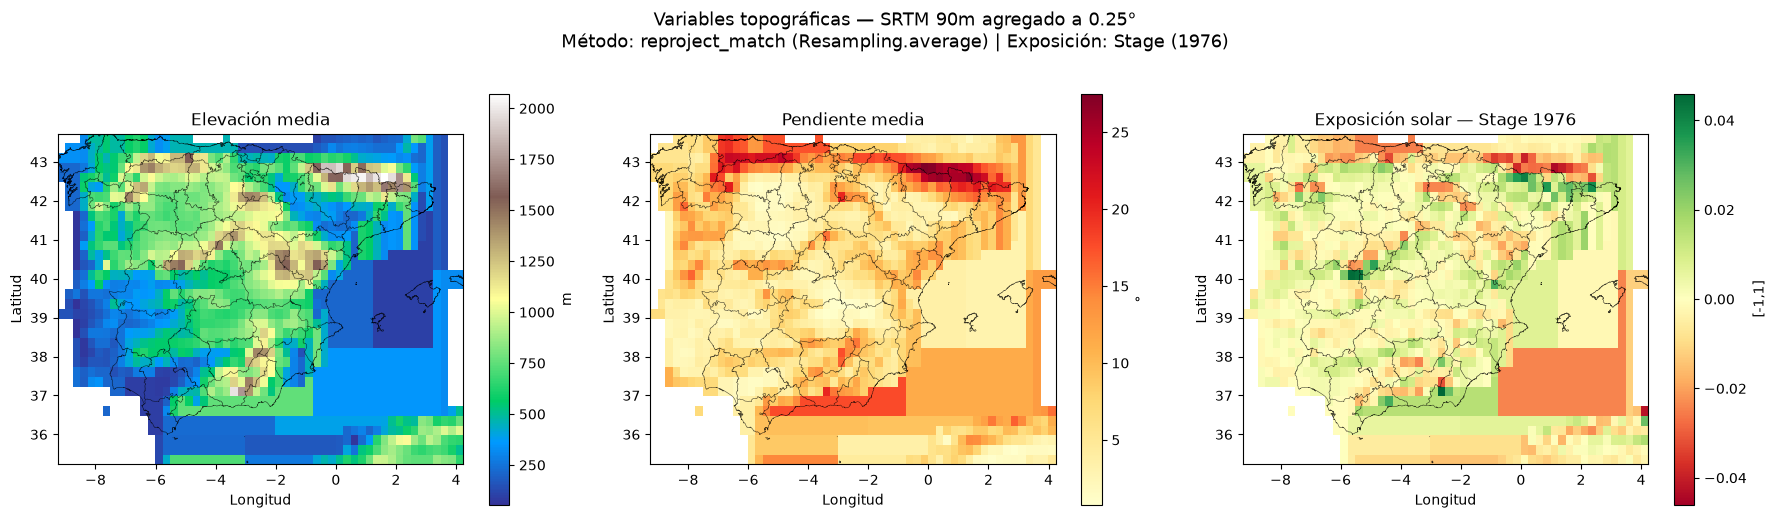

In [29]:
provincias = gpd.read_file(ruta_provincias).to_crs(epsg=4326)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variables_plot = {
    "elevacion":("Elevación media", "m", "terrain"),
    "pendiente":("Pendiente media", "°", "YlOrRd"),
    "exposicion_solar":("Exposición solar — Stage 1976", "[-1,1]", "RdYlGn"),
}

for ax, (var, (titulo, unidad, cmap)) in zip(axes, variables_plot.items()):
    mdt_025[var].plot(ax=ax, cmap=cmap, cbar_kwargs={"label": unidad})
    provincias.plot(ax=ax, color="black", linewidth=0.4, alpha=0.7)
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")

plt.suptitle(
    "Variables topográficas — SRTM 90m agregado a 0.25°\n"
    "Método: reproject_match (Resampling.average) | Exposición: Stage (1976)",
    fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig(FIGURES / "mdt_025_control.png", dpi=300, bbox_inches="tight")
plt.show()

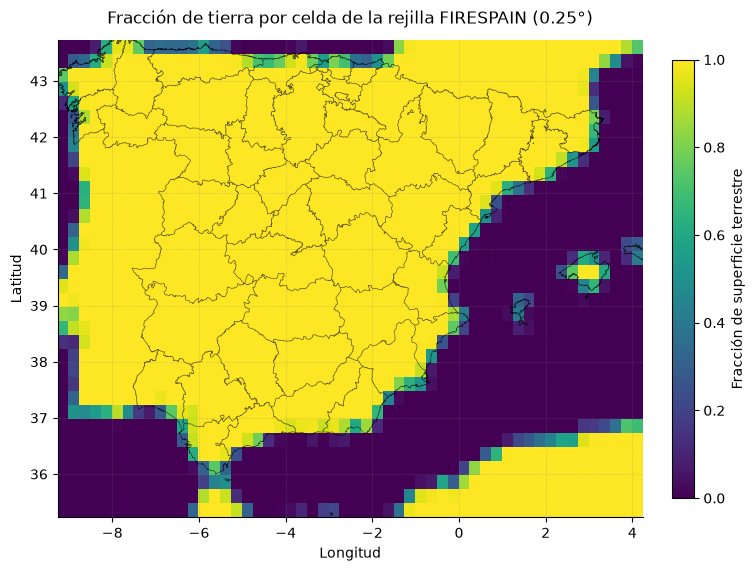

In [30]:
fraccion_tierra = (~np.isnan(elev)).astype(np.float32)
da_land = xr.DataArray(fraccion_tierra, dims=("y","x"), coords={"y":mdt.y,"x":mdt.x})
da_land = da_land.rio.set_spatial_dims(x_dim="x", y_dim="y").rio.write_crs("EPSG:4326")
land025 = da_land.rio.reproject_match(fr25, resampling=Resampling.average)

# Configurar la figura adaptada a un solo mapa
fig, ax = plt.subplots(figsize=(8, 6))

# Configurar barra de color personalizada y compacta (cbar_kwargs)
cbar_opts = {
    "label": "Fracción de superficie terrestre",
    "shrink": 0.8,  # Hace la barra un poco más corta que el mapa
    "pad": 0.04,  # Acerca la barra al mapa
}

land025.plot(ax=ax, cmap="viridis", cbar_kwargs=cbar_opts)

# Superponer tu capa de provincias (manteniendo tu consistencia)
provincias.plot(ax=ax, color="black", linewidth=0.5, alpha=0.6, zorder=2)

# Pulido estético del mapa (Detalles que marcan la diferencia)
ax.set_title(
    "Fracción de tierra por celda de la rejilla FIRESPAIN (0.25°)",
    fontsize=12,
    pad=12,
)
ax.set_xlabel("Longitud", fontsize=10)
ax.set_ylabel("Latitud", fontsize=10)

# Formatear la cuadrícula interna de forma sutil
ax.grid(True, linestyle="--", linewidth=0.5, color="gray", alpha=0.3)

# Eliminar los bordes superior e derecho para un look moderno y limpio
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES / "mdt_land_fraction.png", dpi=300,bbox_inches="tight")
plt.show()

"La validación de la fracción de superficie terrestre mostró que las celdas completamente interiores presentan una cobertura próxima al 100%, mientras que las diferencias observadas tras el remuestreo se concentran exclusivamente en celdas costeras parcialmente ocupadas por el mar. Este comportamiento confirma que los huecos generados por el remuestreo responden a la geometría de las celdas y no a errores del modelo digital de elevaciones."

In [31]:
print("="*60)
print("FRACCIÓN DE TIERRA")
print("="*60)

print(f"Mínimo : {float(land025.min()):.3f}")
print(f"Media  : {float(land025.mean()):.3f}")
print(f"Máximo : {float(land025.max()):.3f}")

print(f"\nCeldas con >95% tierra : {int((land025 > 0.95).sum())}")
print(f"Celdas con 50-95%      : {int(((land025 >= 0.5) & (land025 <= 0.95)).sum())}")
print(f"Celdas con <50% tierra : {int((land025 < 0.5).sum())}")

FRACCIÓN DE TIERRA
Mínimo : 0.000
Media  : 0.646
Máximo : 1.000

Celdas con >95% tierra : 1094
Celdas con 50-95%      : 93
Celdas con <50% tierra : 649


## EXPORTAR DATASET

In [32]:
# ============================================================
# Objetivo: persistir el producto final del bloque MDT.
# exposicion_solar se descarta como feature: varianza
# insuficiente a 0.25° (ver EDA — Stage comprimido en [-0.04,0.04]
# tras la agregación conservativa).
# ============================================================

mdt_025 = mdt_025.rename({"y": "latitude", "x": "longitude"})
mdt_025["elevacion"].attrs  = {"long_name": "Mean elevation", "units": "m"}
mdt_025["pendiente"].attrs = {"long_name": "Mean slope", "units": "degree"}

mdt_final = mdt_025.drop_vars(["exposicion_solar", "spatial_ref"], errors="ignore")
mdt_final.to_netcdf(ruta_mdt_025, mode="w")

print("="*60)
print("MDT — GUARDADO FINAL")
print("="*60)
print(f"Guardado: {ruta_mdt_025}")
print(f"Tamaño:   {ruta_mdt_025.stat().st_size / 1e6:.1f} MB")
print(f"Variables: {list(mdt_final.data_vars)}")
print(f"Grid:      {dict(mdt_final.sizes)}")

MDT — GUARDADO FINAL
Guardado: C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\MDT\mdt_025.nc
Tamaño:   0.0 MB
Variables: ['elevacion', 'pendiente']
Grid:      {'longitude': 54, 'latitude': 34}


# 2.3 CIVIO

In [33]:
# ============================================================
# CIVIO — CARGA Y FILTRADO TEMPORAL
# Período histórico utilizado para construir variables estáticas
# ============================================================
civio = pd.read_csv(ruta_civio, parse_dates=["fecha"])

# Periodo histórico (sin leakage)
civio_hist = civio[civio["fecha"] < "2008-01-01"].copy()

print("="*60)
print("CIVIO — PERÍODO HISTÓRICO")
print("="*60)
print(f"Periodo: desde" f"{civio_hist.fecha.min().date()} hasta " f"{civio_hist.fecha.max().date()}")
print(f"\nIncendios: {len(civio_hist):,}")
print(f"\nCon coordenadas exactas : {(civio_hist.latlng_explicit==1).sum():,}")
print(f"Con centroide municipal : {(civio_hist.latlng_explicit==0).sum():,}")
print(f"Sin coordenadas         : {civio_hist[['lat','lng']].isna().any(axis=1).sum():,}")

CIVIO — PERÍODO HISTÓRICO
Periodo: desde1968-01-01 hasta 2007-12-31

Incendios: 239,709

Con coordenadas exactas : 36,556
Con centroide municipal : 148,761
Sin coordenadas         : 54,431


In [34]:
# ============================================================
# REJILLA FIRESPAIN
# ============================================================
fr25 = xr.open_dataset(ruta_firespain)
lat = fr25.latitude.values
lon = fr25.longitude.values

lat_edges = np.concatenate([
    [lat[0] + 0.125],
    (lat[:-1] + lat[1:]) / 2,
    [lat[-1] - 0.125]
])

lon_edges = np.concatenate([
    [lon[0] - 0.125],
    (lon[:-1] + lon[1:]) / 2,
    [lon[-1] + 0.125]
])

print("="*60)
print("REJILLA FIRESPAIN")
print("="*60)

print(f"Filas    : {len(lat)}")
print(f"Columnas : {len(lon)}")

print(f"\nLatitud : {lat.min():.3f} → {lat.max():.3f}")
print(f"Longitud: {lon.min():.3f} → {lon.max():.3f}")

REJILLA FIRESPAIN
Filas    : 34
Columnas : 54

Latitud : 35.351 → 43.601
Longitud: -9.135 → 4.115


In [35]:
# ============================================================
# PREPARACIÓN ESPACIAL
# ============================================================
# Solo incendios con coordenadas
civio_geo = (civio_hist.dropna(subset=["lat", "lng"]).copy())

# Limitar al dominio FIRESPAIN
civio_geo = civio_geo[
    civio_geo["lat"].between(lat_edges.min(), lat_edges.max())
    &
    civio_geo["lng"].between(lon_edges.min(), lon_edges.max())
].copy()

# Índice de columna
col = (np.searchsorted(lon_edges, civio_geo["lng"].values, side="right") - 1)

# Índice de fila
lat_edges_asc = np.sort(lat_edges)

row = (len(lat) - np.searchsorted(lat_edges_asc, civio_geo["lat"].values, side="right"))

civio_geo["row"] = row.astype(np.int16)
civio_geo["col"] = col.astype(np.int16)

print("="*60)
print("PREPARACIÓN ESPACIAL")
print("="*60)

print(f"Incendios dentro del dominio: {len(civio_geo):,}")

PREPARACIÓN ESPACIAL
Incendios dentro del dominio: 184,539


In [36]:
# ============================================================
# VERIFICACIÓN DE LA ASIGNACIÓN
# ============================================================

assert civio_geo["row"].between(0, len(lat)-1).all()
assert civio_geo["col"].between(0, len(lon)-1).all()

print("="*60)
print("VERIFICACIÓN")
print("="*60)

print(f"Incendios asignados: {len(civio_geo):,}")

print("\n✓ Todos los incendios poseen índices válidos.")

VERIFICACIÓN
Incendios asignados: 184,539

✓ Todos los incendios poseen índices válidos.


In [37]:
# ============================================================
# DENSIDAD HISTÓRICA DE IGNICIONES (1968–2007)
# ============================================================
densidad_total = np.zeros((len(lat), len(lon)), dtype=np.int32)
densidad_exacta = np.zeros_like(densidad_total)

rows = civio_geo["row"].to_numpy()
cols = civio_geo["col"].to_numpy()

exacta = civio_geo["latlng_explicit"].fillna(0).eq(1).to_numpy()

# Todos los incendios
np.add.at(densidad_total, (rows, cols), 1)

# Sólo coordenadas exactas
np.add.at(densidad_exacta, (rows[exacta], cols[exacta]), 1)

print("="*60)
print("DENSIDADES")
print("="*60)

print(f"Total incendios contabilizados : {densidad_total.sum():,}")
print(f"Exactos contabilizados         : {densidad_exacta.sum():,}")

DENSIDADES
Total incendios contabilizados : 184,539
Exactos contabilizados         : 36,495


In [38]:
# ============================================================
# COMPARACIÓN ESTADÍSTICA
# ============================================================
mask = densidad_total >= 10

x = densidad_total[mask]
y = densidad_exacta[mask]

pearson = pearsonr(x, y)[0]
spearman = spearmanr(x, y)[0]

mae = mean_absolute_error(x, y)
rmse = np.sqrt(mean_squared_error(x, y))

print("="*60)
print("COMPARACIÓN")
print("="*60)

print(f"Celdas analizadas : {mask.sum()}")
print(f"Pearson           : {pearson:.3f}")
print(f"Spearman          : {spearman:.3f}")
print(f"MAE               : {mae:.2f}")
print(f"RMSE              : {rmse:.2f}")

COMPARACIÓN
Celdas analizadas : 893
Pearson           : 0.826
Spearman          : 0.653
MAE               : 165.54
RMSE              : 340.17


In [39]:
# ============================================================
# DISTRIBUCIÓN ESPACIAL
# ============================================================

print("="*60)
print("DISTRIBUCIÓN DE DENSIDADES")
print("="*60)

for n in [1,5,10,20,50]:
    celdas = (densidad_total>=n).sum()
    print(f"Celdas con ≥{n:2d} incendios : {celdas}")

DISTRIBUCIÓN DE DENSIDADES
Celdas con ≥ 1 incendios : 954
Celdas con ≥ 5 incendios : 926
Celdas con ≥10 incendios : 893
Celdas con ≥20 incendios : 821
Celdas con ≥50 incendios : 560


In [40]:
# ============================================================
# COMPARACIÓN ESPACIAL
# ============================================================

coords = {"y": lat, "x": lon}

ds_compare = xr.Dataset({
    "densidad_total":
        (["y","x"], densidad_total),

    "densidad_exacta":
        (["y","x"], densidad_exacta),

    "diferencia":
        (["y","x"], densidad_total-densidad_exacta)

},coords=coords)

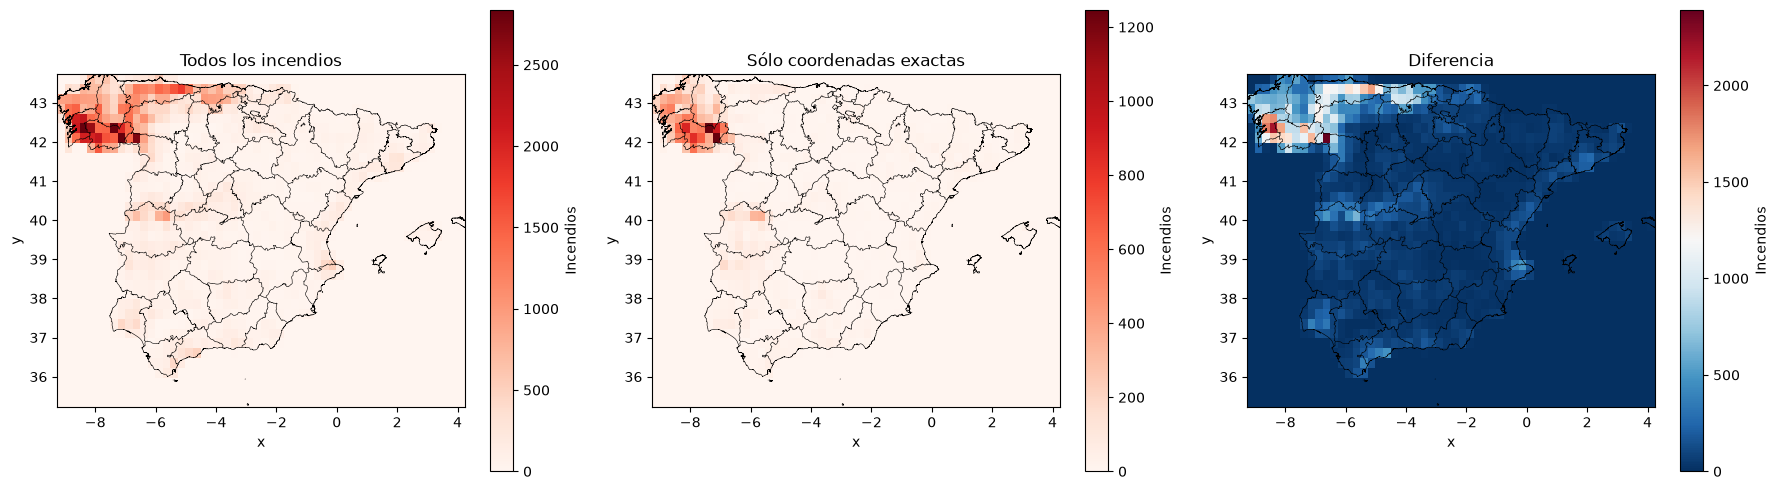

In [41]:
provincias = gpd.read_file(ruta_provincias).to_crs(4326)
fig,axes = plt.subplots(1,3,figsize=(18,5))

variables = {
    "densidad_total":
        ("Todos los incendios","Reds"),

    "densidad_exacta":
        ("Sólo coordenadas exactas","Reds"),

    "diferencia":
        ("Diferencia","RdBu_r")
}

for ax,(var,(titulo,cmap)) in zip(axes,variables.items()):
    ds_compare[var].plot(
        ax=ax,
        cmap=cmap,
        cbar_kwargs={"label":"Incendios"})
    
    provincias.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=0.4)
    
    ax.set_title(titulo)

plt.tight_layout()
plt.savefig(FIGURES/"comparacion_densidades_civio.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
# ============================================================
# CAUSAS DE IGNICIÓN
# ============================================================
causas_conocidas = civio_geo[civio_geo["causa"].isin([1,2,3])].copy()
causas_conocidas["antropica"] = (causas_conocidas["causa"].isin([2,3]))
causas_conocidas["rayo"] = (causas_conocidas["causa"]==1)

In [43]:
# ============================================================
# VARIABLES DE CAUSALIDAD
# ============================================================

# Solo incendios con causa conocida
causas = civio_geo[civio_geo["causa"].isin([1, 2, 3])].copy()

# Arrays auxiliares
causas_conocidas = np.zeros((len(lat), len(lon)), dtype=np.int32)
causas_rayo      = np.zeros_like(causas_conocidas)
causas_humanas   = np.zeros_like(causas_conocidas)

rows = causas["row"].to_numpy()
cols = causas["col"].to_numpy()

mask_rayo = causas["causa"].to_numpy() == 1
mask_humana = np.isin(causas["causa"].to_numpy(), [2, 3])

# Conteos
np.add.at(causas_conocidas, (rows, cols), 1)

np.add.at(
    causas_rayo,
    (rows[mask_rayo], cols[mask_rayo]),
    1
)

np.add.at(
    causas_humanas,
    (rows[mask_humana], cols[mask_humana]),
    1
)

print("="*60)
print("CAUSAS DE IGNICIÓN")
print("="*60)

print(f"Causas conocidas : {causas_conocidas.sum():,}")
print(f"Naturales (rayo) : {causas_rayo.sum():,}")
print(f"Antrópicas       : {causas_humanas.sum():,}")

CAUSAS DE IGNICIÓN
Causas conocidas : 34,359
Naturales (rayo) : 4,057
Antrópicas       : 30,302


In [44]:
# ============================================================
# PORCENTAJES POR CELDA
# ============================================================

pct_causa_rayo = np.divide(
    causas_rayo,
    causas_conocidas,
    out=np.zeros_like(causas_rayo, dtype=np.float32),
    where=causas_conocidas > 0
)

pct_causa_antropica = np.divide(
    causas_humanas,
    causas_conocidas,
    out=np.zeros_like(causas_humanas, dtype=np.float32),
    where=causas_conocidas > 0
)

print("="*60)
print("PORCENTAJES")
print("="*60)

print(f"Rayo")
print(f"  Min : {pct_causa_rayo.min():.3f}")
print(f"  Max : {pct_causa_rayo.max():.3f}")
print(f"  Mean: {pct_causa_rayo.mean():.3f}")

print()

print(f"Antrópica")
print(f"  Min : {pct_causa_antropica.min():.3f}")
print(f"  Max : {pct_causa_antropica.max():.3f}")
print(f"  Mean: {pct_causa_antropica.mean():.3f}")

PORCENTAJES
Rayo
  Min : 0.000
  Max : 1.000
  Mean: 0.066

Antrópica
  Min : 0.000
  Max : 1.000
  Mean: 0.446


In [45]:
# ============================================================
# VARIABLES DE CAUSALIDAD
# ============================================================

coords = {"y": lat, "x": lon}

ds_plot = xr.Dataset({
    "pct_causa_rayo":
        (["y","x"], pct_causa_rayo),
    "pct_causa_antropica":
        (["y","x"], pct_causa_antropica)

},coords=coords)

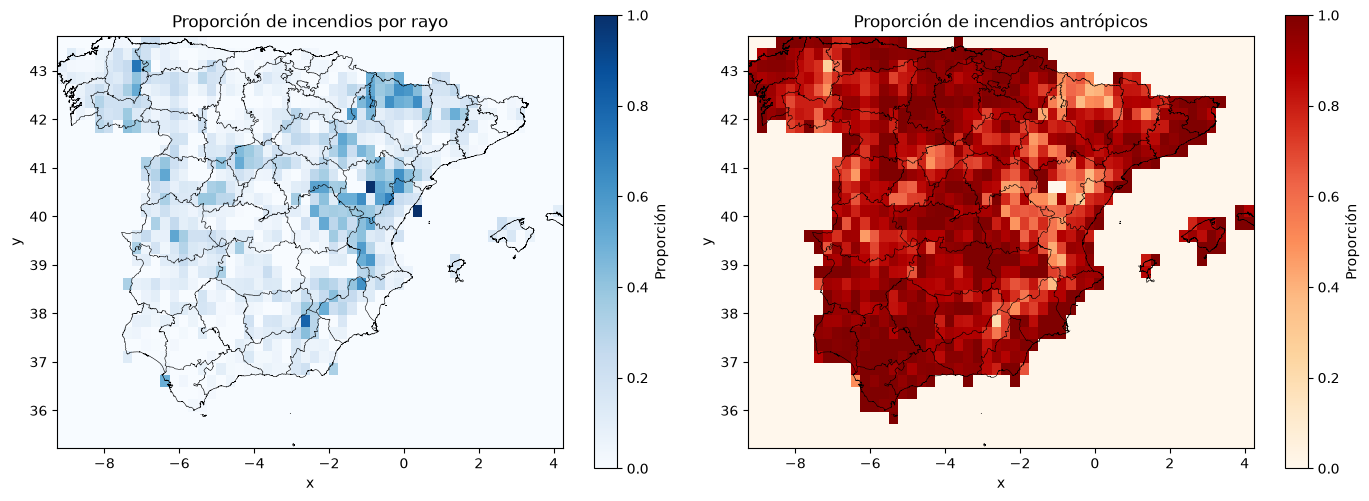

In [46]:
provincias = gpd.read_file(ruta_provincias).to_crs(4326)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

variables = {
    "pct_causa_rayo":
        ("Proporción de incendios por rayo", "Blues"),
    "pct_causa_antropica":
        ("Proporción de incendios antrópicos", "OrRd")
}

for ax, (var, (titulo, cmap)) in zip(axes, variables.items()):
    ds_plot[var].plot(
        ax=ax,
        cmap=cmap,
        vmin=0,
        vmax=1,
        cbar_kwargs={"label": "Proporción"}
    )
    provincias.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=0.4
    )
    ax.set_title(titulo)

plt.tight_layout()
plt.savefig(FIGURES / "civio_causalidad.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
# ============================================================
# DECISIÓN METODOLÓGICA
# ============================================================
# Pearson = 0.826, Spearman = 0.653, MAE = 165.5, RMSE = 340.2
#
# Aunque ambas variables presentan una correlación moderada,
# el análisis espacial evidencia diferencias relevantes entre
# distribuciones. Limitar el cálculo únicamente a coordenadas
# exactas supone:
#
#   • descartar el 80.3% de los incendios georreferenciados
#   • subestimar la densidad histórica en amplias regiones
#   • alterar el patrón espacial observado en la serie histórica
#
# Se selecciona densidad_total, ya que la incertidumbre asociada
# al uso de centroides municipales se considera aceptable a la
# resolución de trabajo (0.25° ≈ 28 km).
# ============================================================

In [48]:
variable_seleccionada = "densidad_total"

In [49]:
coords = {"latitude": lat, "longitude": lon}

ds_civio_features = xr.Dataset({
    "densidad_igniciones": (
        ["latitude", "longitude"],
        densidad_total.astype(np.int32),
        {"long_name": "Historical wildfire density",
         "units": "count",
         "note": "Includes all ignitions (exact + municipal centroid coordinates)"}
    ),
    "pct_causa_antropica": (
        ["latitude", "longitude"],
        pct_causa_antropica.astype(np.float32),
        {"long_name": "Proportion of anthropogenic wildfire ignitions",
         "units": "fraction [0-1]",
         "note": "Calculated over known causes only (causa 1,2,3)"}
    ),
    "pct_causa_rayo": (
        ["latitude", "longitude"],
        pct_causa_rayo.astype(np.float32),
        {"long_name": "Proportion of lightning-caused wildfire ignitions",
         "units": "fraction [0-1]",
         "note": "Calculated over known causes only (causa 1,2,3)"}
    ),
}, coords=coords)

ruta_civio_features = DATA / "CIVIO" / "civio_features.nc"
ds_civio_features.to_netcdf(ruta_civio_features, mode="w")

print(f"Guardado: {ruta_civio_features}")
print(ds_civio_features)

Guardado: C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\CIVIO\civio_features.nc
<xarray.Dataset> Size: 23kB
Dimensions:              (latitude: 34, longitude: 54)
Coordinates:
  * latitude             (latitude) float64 272B 43.6 43.35 43.1 ... 35.6 35.35
  * longitude            (longitude) float64 432B -9.135 -8.885 ... 3.865 4.115
Data variables:
    densidad_igniciones  (latitude, longitude) int32 7kB 0 0 0 169 ... 0 0 0 0
    pct_causa_antropica  (latitude, longitude) float32 7kB 0.0 0.0 ... 0.0 0.0
    pct_causa_rayo       (latitude, longitude) float32 7kB 0.0 0.0 ... 0.0 0.0
